# 1&nbsp; Initialization

## Imports

In [1]:
# Python standard library packages to do file/folder manipulations,
# pickle is a package to store python variables
import glob, os, pickle, time

# this packages helps load and save .mat files older than v7
import hdf5storage

# numpy works with arrays, pandas used to work with fancy numpy arrays
import numpy as np
import pandas as pd

# matplotlib is used to plot and animate to make movies
import matplotlib.pyplot as plt

# Scikit-learn is a go-to library in Python for all things machine learning
from sklearn.decomposition import PCA

# Configuring matplotlib to show animations in a colab notebook as javascript
# objects for easier viewing.
from matplotlib import rc
rc('animation', html='jshtml')

from InfluxDBInterface.libdb import download_tmp_DB, download_data_DB, download_co2_DB

## Configuration

In [2]:
WideNormalisation = True # Whether to normalise all data across datasets (True) or normalise each dataset independently (False)
projectPath = r"/Users/cyrilmonette/Desktop/EPFL 2018-2026/PhD - Mobots/PdS/(25b) Ethograms/Ethogram-Generation/Results/WideNormalisation"

## Dataset(s) loading

In [3]:
def download_dataset(hive_nb:int, ihl:str, start_ts:pd.Timestamp, end_ts:pd.Timestamp, resolution:int=600):
    """
    Download the dataset for a given hive number and in-hive location.
    """
    assert ihl in ["upper", "lower"], "inhive_loc must be either 'upper' or 'lower'"
    assert hive_nb in [1, 2], "hive_num must be either 1 or 2"
    filters = {
        "hive_num" : hive_nb,
        "inhive_loc" : ihl,
    }
    df = download_tmp_DB('ObsHiveABC', start_ts, end_ts, resolution = resolution, filters = filters, aggr = "last")
    
    # remove "inhive_loc" key from filters
    filters.pop("inhive_loc")
    co2_data = download_co2_DB('ObsHiveABC', start_ts, end_ts, resolution = resolution, filters = filters)
    # Keep only the columns that start with the same letter as the first letter of ihl (i.e. "u" for "upper" and "l" for "lower")
    co2_data = co2_data.loc[:, co2_data.columns.str.startswith(ihl[0])]
    for col in co2_data.columns:
        col_name = f"co2_{col[-1].upper()}"
        df[col_name] = co2_data.loc[:,col] # This should add 2 columns: (ul and ur) OR (ll and lr)
    
    # Add a _field tag and _measurement tag to filters
    filters["field"] = ["rel_humid"]
    filters["measurement"] = ["co2", "rht"]
    filters["inhive_loc"] = ihl
    humid_data = download_data_DB('ObsHiveABC', start_ts, end_ts, resolution = resolution, filters = filters)
    
    # For every ts in df, there are several ts in humid_data. We want to take the average of the values in humid_data for each ts in df_resampled and store it in the "rel_humid" column of df_resampled.
    df["rel_humid"] = df.index.to_series().apply(lambda ts: humid_data.loc[humid_data.index == ts, "_value"].mean())
    
    # Filter out timestamps not allowed by HiveOpenings
    from HiveOpenings.libOpenings import filter_timestamps
    print("Before filtering with HiveOpenings:", len(df), "lines")
    filtered_ts = filter_timestamps(df.index.to_list(), hive_nb=hive_nb, recovery_time=240)
    df_resampled = df[df.index.isin(filtered_ts)]
    print("After  :", len(df_resampled), "lines")
    
    return df_resampled

In [4]:
df1_resampled = download_dataset(hive_nb=2, ihl="upper", 
                                 start_ts=pd.Timestamp('2024-10-03 01:00:00Z'), 
                                 end_ts=pd.Timestamp('2024-10-29 23:00:00Z'),
                                 resolution=600)

print(df1_resampled.head())

Before filtering with HiveOpenings: 3571 lines
After  : 3391 lines
                              t00        t01        t02        t03        t04        t05        t06        t07        t08        t09        t10        t11        t12        t13        t14        t15        t16        t17        t18        t19        t20        t21        t22        t23        t24        t25        t26        t27        t28        t29        t30        t31        t32        t33        t34        t35        t36        t37        t38        t39        t40        t41        t42        t43        t44        t45        t46        t47        t48        t49        t50        t51        t52        t53        t54        t55        t56        t57        t58        t59        t60        t61        t62        t63     co2_L  co2_R  rel_humid
datetime                                                                                                                                                                          

In [5]:
df2_resampled = download_dataset(hive_nb=1, ihl="upper", 
                                 start_ts=pd.Timestamp('2024-09-04 01:00:00Z'), 
                                 end_ts=pd.Timestamp('2024-10-29 23:00:00Z'),
                                 resolution=600)

print(df2_resampled.head())

Before filtering with HiveOpenings: 7728 lines
After  : 7244 lines
                              t00        t01        t02        t03        t04        t05        t06        t07        t08        t09        t10        t11        t12        t13        t14        t15        t16        t17        t18        t19        t20        t21        t22        t23        t24        t25        t26        t27        t28        t29        t30        t31        t32        t33        t34        t35        t36        t37        t38        t39        t40        t41        t42        t43        t44        t45        t46        t47        t48        t49        t50        t51        t52        t53        t54        t55        t56        t57        t58        t59        t60        t61        t62        t63     co2_L  co2_R  rel_humid
datetime                                                                                                                                                                          

In [6]:
df3_resampled = download_dataset(hive_nb=2, ihl="lower", 
                                 start_ts=pd.Timestamp('2024-10-01 01:00:00Z'), 
                                 end_ts=pd.Timestamp('2024-10-29 23:00:00Z'),
                                 resolution=600)

print(df3_resampled.head())

Before filtering with HiveOpenings: 3704 lines
After  : 3491 lines
                              t00        t01        t02        t03        t04        t05        t06        t07        t08        t09        t10        t11        t12        t13        t14        t15        t16        t17        t18        t19        t20        t21        t22        t23        t24        t25        t26        t27        t28        t29        t30        t31        t32        t33        t34        t35        t36        t37        t38        t39        t40        t41        t42        t43        t44        t45        t46        t47        t48        t49        t50        t51        t52        t53        t54        t55        t56        t57        t58        t59        t60        t61        t62        t63     co2_L  co2_R  rel_humid
datetime                                                                                                                                                                          

In [12]:
df_list = [df1_resampled, df2_resampled, df3_resampled]

# Drop any NaN values that may still exist after resampling
df_list_dropna = []
for df in df_list:
    len_before = len(df)
    df = df.dropna(how='any')
    df_list_dropna.append(df)
    print("Dropped", len_before - len(df), "lines with NaN values. Remaining lines:", len(df))

Dropped 314 lines with NaN values. Remaining lines: 3077
Dropped 1960 lines with NaN values. Remaining lines: 5284
Dropped 315 lines with NaN values. Remaining lines: 3176


In [13]:
df_nat = []

for i, df in enumerate(df_list_dropna, start=1):

    df = df.copy()

    # 1) Save the real timestamp
    df["real_timestamp"] = df.index

    # 2) move each dataset's timestamp by i * 75 years to prepare for wavelet transform
    df.index = df.index + pd.DateOffset(years=75 * i)

    # 3) add a source id column
    df["source_id"] = i

    df_nat.append(df)

# 4) concatenate all dataframes into one
df_nat = pd.concat(df_nat, axis=0)
df_nat = df_nat.sort_index()

print(df_nat[["real_timestamp", "source_id"]].head())

                                real_timestamp       source_id
datetime                                                      
2099-10-03 17:00:00+00:00 2024-10-03 17:00:00+00:00      1    
2099-10-03 17:10:00+00:00 2024-10-03 17:10:00+00:00      1    
2099-10-03 17:20:00+00:00 2024-10-03 17:20:00+00:00      1    
2099-10-03 17:30:00+00:00 2024-10-03 17:30:00+00:00      1    
2099-10-03 17:40:00+00:00 2024-10-03 17:40:00+00:00      1    


Raw Data Plots

In [20]:
df_plots = df_list_dropna[0].copy()

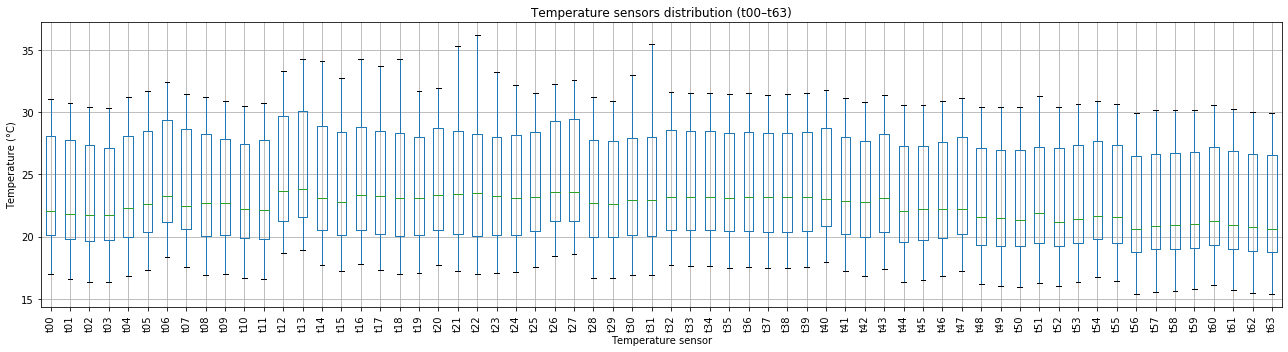

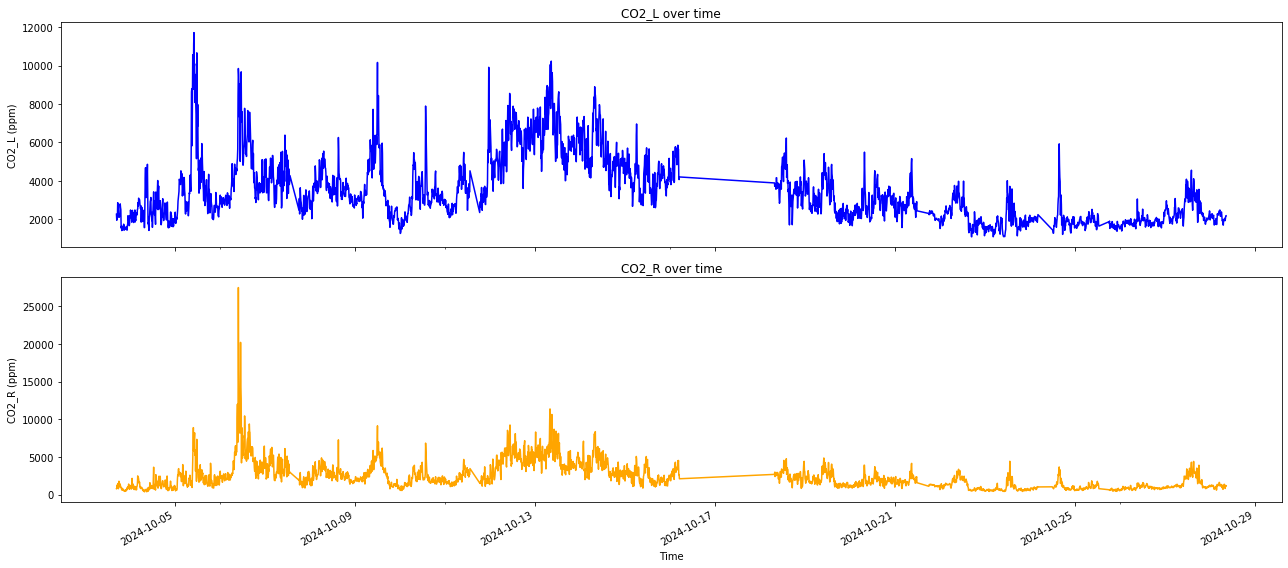

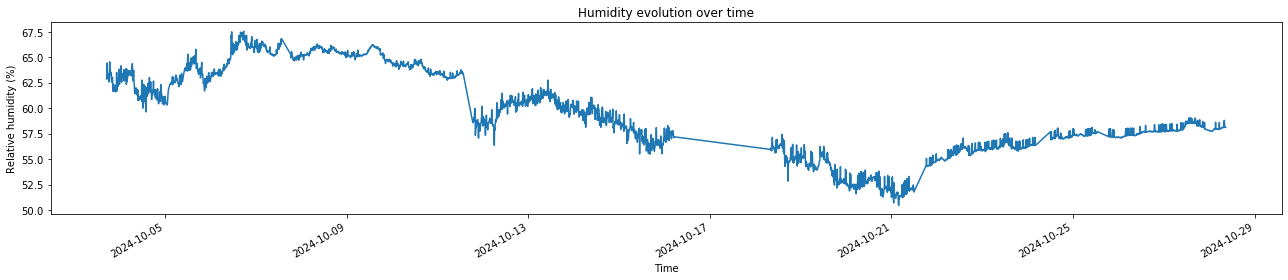

In [22]:
# --- Columns ---
temp_cols = [f"t{str(i).zfill(2)}" for i in range(64)]  # t00..t63
co2_col = ["co2_L", "co2_R"]
humid_col = "rel_humid"

# =========================
# 1) Boxplots for temperature sensors (t00..t63)
# =========================
ax = df_plots[temp_cols].boxplot(figsize=(18, 5), rot=90,showfliers=False)
ax.set_xlabel("Temperature sensor")
ax.set_ylabel("Temperature (°C)")
ax.set_title("Temperature sensors distribution (t00–t63)")
plt.tight_layout()
plt.show()

# =========================
# 2) CO2 over time (separate figure)
# =========================
# Make a two-row plot for CO2_L and CO2_R, sharig the same x-axis
fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(18, 8), sharex=True)
df_plots[co2_col[0]].plot(ax=axs[0], color='blue', title='CO2_L over time')
axs[0].set_ylabel("CO2_L (ppm)")
df_plots[co2_col[1]].plot(ax=axs[1], color='orange', title='CO2_R over time')
axs[1].set_xlabel("Time")
axs[1].set_ylabel("CO2_R (ppm)")
plt.tight_layout()
plt.show()

# =========================
# 3) Humidity over time (separate figure)
# =========================
ax = df_plots[humid_col].plot(figsize=(18, 4))
ax.set_xlabel("Time")
ax.set_ylabel("Relative humidity (%)")
ax.set_title("Humidity evolution over time")
plt.tight_layout()
plt.show()


# 2&nbsp; Preprocessing of Data

## Scaling

First we shift the timestamps to separate datasets temporaly

In [23]:
df_shifted = []

for i, df in enumerate(df_list_dropna, start=1):

    df = df.copy()

    # move each dataset's timestamp by i * 75 years for wavelet transform purposes
    df.index = df.index + pd.DateOffset(years=75*i)

    # add a source id column
    df["source_id"] = i

    df_shifted.append(df)

# Concatenate into one DataFrame
df_concat = pd.concat(df_shifted, axis=0)
df_concat = df_concat.sort_index()

print(df_concat.index[:10])
print(len(df_concat))

DatetimeIndex(['2099-10-03 17:00:00+00:00', '2099-10-03 17:10:00+00:00', '2099-10-03 17:20:00+00:00', '2099-10-03 17:30:00+00:00', '2099-10-03 17:40:00+00:00', '2099-10-03 17:50:00+00:00', '2099-10-03 18:00:00+00:00', '2099-10-03 18:10:00+00:00', '2099-10-03 18:20:00+00:00', '2099-10-03 18:30:00+00:00'], dtype='datetime64[ns, tzutc()]', name='datetime', freq=None)
11537


Then we scale all values

In [24]:
if WideNormalisation:
    df_scaled = df_concat.copy()
    # We normalise all datasets together
    # Temperature columns
    temp_cols = [f"t{i:02d}" for i in range(64)]
    print("Temperature columns:", temp_cols)
    temp_mean = df_scaled[temp_cols].values.mean()
    print("Temperature mean:", temp_mean)
    temp_std = df_scaled[temp_cols].values.std()
    print("Temperature std:", temp_std)

    df_scaled[temp_cols] = (df_scaled[temp_cols] - temp_mean) / temp_std

    # CO2 columns
    co2_cols = ["co2_L", "co2_R"]
    co2_mean = df_scaled[co2_cols].values.mean()
    co2_std = df_scaled[co2_cols].values.std()

    df_scaled[co2_cols] = (df_scaled[co2_cols] - co2_mean) / co2_std

else:
    dfs_scaled = []
    for dataset_id in df_concat["source_id"].unique():
        dataset_df = df_concat[df_concat["source_id"] == dataset_id]
        from sklearn.preprocessing import StandardScaler

        # We only keep numerical columns for scaling
        X = dataset_df.select_dtypes(include='number')

        # Normalization
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)

        # Create a normalized DataFrame
        X_scaled = pd.DataFrame(X_scaled, columns=X.columns, index=dataset_df.index)
        dfs_scaled.append(X_scaled)

    df_scaled = pd.concat(dfs_scaled, axis=0)

Temperature columns: ['t00', 't01', 't02', 't03', 't04', 't05', 't06', 't07', 't08', 't09', 't10', 't11', 't12', 't13', 't14', 't15', 't16', 't17', 't18', 't19', 't20', 't21', 't22', 't23', 't24', 't25', 't26', 't27', 't28', 't29', 't30', 't31', 't32', 't33', 't34', 't35', 't36', 't37', 't38', 't39', 't40', 't41', 't42', 't43', 't44', 't45', 't46', 't47', 't48', 't49', 't50', 't51', 't52', 't53', 't54', 't55', 't56', 't57', 't58', 't59', 't60', 't61', 't62', 't63']
Temperature mean: 25.42154486947904
Temperature std: 5.078431892479634


In [25]:
df_merged = df_scaled.drop(columns=['source_id']).copy()
print(df_merged.columns)

Index(['t00', 't01', 't02', 't03', 't04', 't05', 't06', 't07', 't08', 't09', 't10', 't11', 't12', 't13', 't14', 't15', 't16', 't17', 't18', 't19', 't20', 't21', 't22', 't23', 't24', 't25', 't26', 't27', 't28', 't29', 't30', 't31', 't32', 't33', 't34', 't35', 't36', 't37', 't38', 't39', 't40', 't41', 't42', 't43', 't44', 't45', 't46', 't47', 't48', 't49', 't50', 't51', 't52', 't53', 't54', 't55', 't56', 't57', 't58', 't59', 't60', 't61', 't62', 't63', 'co2_L', 'co2_R', 'rel_humid'], dtype='object')


In [26]:
# Final check : dropna for the PCA
df_merged = df_merged.dropna(how="any")

## PCA
Compute PCA on the concatenated dataset

In [27]:
#Parameter for PCA
variance_threshold = 0.99

We'll pick the first 4 components that explain 99.0% of the variance.


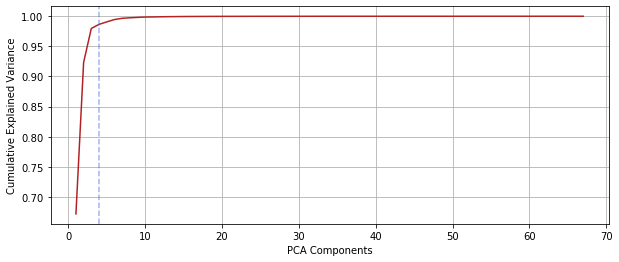

In [28]:
x = df_merged

#We are using sklearn.decomposition.PCA here
p = PCA()
y = p.fit_transform(x)

fig, ax = plt.subplots(figsize=(10,4))
ax.plot(np.arange(1, x.shape[1]+1), np.cumsum(p.explained_variance_ratio_), color='firebrick')

#This calculates the number of PCA components required to surpass the variance threshold
comps_above_thresh = np.argwhere(np.cumsum(p.explained_variance_ratio_)>variance_threshold)[0][0]

ax.axvline(x=comps_above_thresh, color='royalblue', linestyle='--', alpha=0.5)
#ax.text(x = comps_above_thresh + 1, y = 0.5, s=f'{comps_above_thresh}th component')
ax.set_xlabel('PCA Components')
ax.set_ylabel('Cumulative Explained Variance')
ax.grid()

print(f'We\'ll pick the first {comps_above_thresh} components that explain {variance_threshold*100}% of the variance.')

PCA Components Visualization

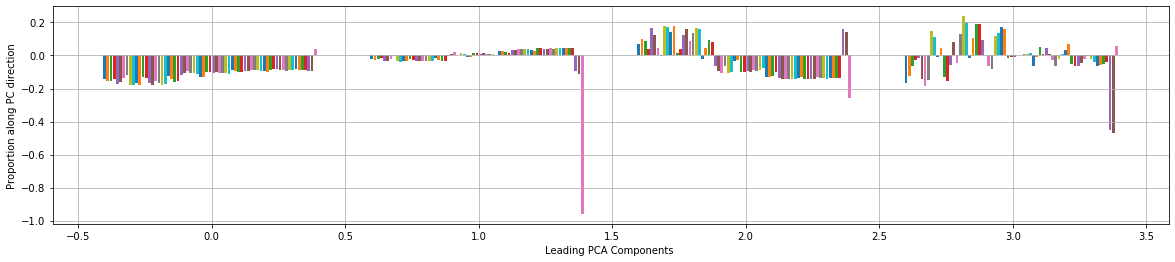

In [29]:
fig, ax = plt.subplots(figsize=(20,4))

for i in range(comps_above_thresh):
  for pi in range(x.shape[1]):
    ax.bar((i-0.4+pi*(0.8/x.shape[1])), p.components_[i, pi], width=(0.7/x.shape[1]), label=f'Angle{i}')
  ax.set_prop_cycle(None)

ax.set_xlabel('Leading PCA Components ')
ax.set_ylabel('Proportion along PC direction')
# ax.legend()
ax.grid()
plt.show()

Picking PCA Components

In [30]:
#picking PCA components above threshold
y = y[:,:comps_above_thresh]
print(y.shape)

(11537, 4)


# 3.&nbsp; Creating an mmpy project directory

Setup Folders

In [31]:
import motionmapperpy as mmpy
%matplotlib inline

# This creates a project directory structure which will be used to store all motionmappery pipeline
# related data in one place.

mmpy.createProjectDirectory(projectPath)

hdf5storage.savemat(f'{projectPath}/Projections/observation_OH_pcaModes.mat', {'projections': y})

Creating : /Users/cyrilmonette/Desktop/EPFL 2018-2026/PhD - Mobots/PdS/(25b) Ethograms/Ethogram-Generation/Results/WideNormalisation
Creating : /Users/cyrilmonette/Desktop/EPFL 2018-2026/PhD - Mobots/PdS/(25b) Ethograms/Ethogram-Generation/Results/WideNormalisation/Projections
Creating : /Users/cyrilmonette/Desktop/EPFL 2018-2026/PhD - Mobots/PdS/(25b) Ethograms/Ethogram-Generation/Results/WideNormalisation/TSNE_Projections
Creating : /Users/cyrilmonette/Desktop/EPFL 2018-2026/PhD - Mobots/PdS/(25b) Ethograms/Ethogram-Generation/Results/WideNormalisation/TSNE
Creating : /Users/cyrilmonette/Desktop/EPFL 2018-2026/PhD - Mobots/PdS/(25b) Ethograms/Ethogram-Generation/Results/WideNormalisation/UMAP


Setup Parameters

In [32]:
# Important parameters for Wavelet Transform are : minF, maxF, samplingFreq, numPeriods
# Important parameters for UMAP are : n_neighbors, min_dist

In [33]:
#% Load the default parameters.
parameters = mmpy.setRunParameters()

# %%%%%%% PARAMETERS TO CHANGE %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
# These need to be revised everytime you are working with a new dataset. #

parameters.projectPath = projectPath #% Full path to the project directory.


parameters.method = 'UMAP' #% We can choose between 'TSNE' or 'UMAP'

parameters.minF = 1/(24*3600)        #% Minimum frequency for Morlet Wavelet Transform

parameters.maxF = 1/(3600)       #% Maximum frequency for Morlet Wavelet Transform,
                           #% usually equal to the Nyquist frequency for your
                           #% measurements.

parameters.samplingFreq = 1/(600)   #% Sampling frequency (or FPS) of data.

parameters.numPeriods = 200      #% No. of dyadically spaced frequencies to
                                 #% calculate between minF and maxF.

parameters.pcaModes = comps_above_thresh #% Number of low-d features.

parameters.numProcessors = -1     #% No. of processor to use when parallel
                                 #% processing for wavelet calculation (if not using GPU)
                                 #% and for re-embedding. -1 to use all cores
                                 #% available.

parameters.useGPU = -1           #% GPU to use for wavelet calculation,
                                 #% set to -1 if GPU not present.

parameters.training_numPoints = 5000    #% Number of points in mini-trainings.


# %%%%% NO NEED TO CHANGE THESE UNLESS MEMORY ERRORS OCCUR %%%%%%%%%%

parameters.trainingSetSize = 5000  #% Total number of training set points to find.
                                 #% Increase or decrease based on
                                 #% available RAM. For reference, 36k is a
                                 #% good number with 64GB RAM.

parameters.embedding_batchSize = 50000  #% Lower this if you get a memory error when
                                        #% re-embedding points on a learned map.

# %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

In [34]:
# %%%%%%% tSNE parameters %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

#% can be 'barnes_hut' or 'exact'. We'll use barnes_hut for this tutorial for speed.
parameters.tSNE_method = 'barnes_hut'

# %2^H (H is the transition entropy)
parameters.perplexity = 32

# %number of neigbors to use when re-embedding
parameters.maxNeighbors = 200

# %local neighborhood definition in training set creation
parameters.kdNeighbors = 5

# %t-SNE training set perplexity
parameters.training_perplexity = 20


# %%%%%%%% UMAP Parameters %%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

# Size of local neighborhood for UMAP.
parameters.n_neighbors = 50

# Negative sample rate while training.
parameters.train_negative_sample_rate = 5

# Negative sample rate while embedding new data.
parameters.embed_negative_sample_rate = 1

# Minimum distance between neighbors.
parameters.min_dist = 0.1

In [35]:
parameters

{'numProcessors': -1,
 'numPeriods': 200,
 'omega0': 5,
 'samplingFreq': 0.0016666666666666668,
 'minF': 1.1574074074074073e-05,
 'maxF': 0.0002777777777777778,
 'tSNE_method': 'barnes_hut',
 'perplexity': 32,
 'embedding_batchSize': 50000,
 'maxOptimIter': 100,
 'trainingSetSize': 5000,
 'maxNeighbors': 200,
 'kdNeighbors': 5,
 'training_perplexity': 20,
 'training_numPoints': 5000,
 'minTemplateLength': 1,
 'waveletDecomp': True,
 'useGPU': -1,
 'n_neighbors': 50,
 'train_negative_sample_rate': 5,
 'embed_negative_sample_rate': 1,
 'min_dist': 0.1,
 'umap_output_dims': 2,
 'n_training_epochs': 1000,
 'rescale_max': 100,
 'method': 'UMAP',
 'projectPath': '/Users/cyrilmonette/Desktop/EPFL 2018-2026/PhD - Mobots/PdS/(25b) Ethograms/Ethogram-Generation/Results/WideNormalisation',
 'pcaModes': 4}

# 4.&nbsp; Creating a training set and embedding it using UMAP

In [36]:
t1 = time.time()

mmpy.subsampled_tsne_from_projections(parameters, parameters.projectPath)

print(f'Done in {time.time()-t1} seconds.')

Finding Training Set
Finding training set contributions from data set 1/1 : 
/Users/cyrilmonette/Desktop/EPFL 2018-2026/PhD - Mobots/PdS/(25b) Ethograms/Ethogram-Generation/Results/WideNormalisation/Projections/observation_OH_pcaModes.mat
	 Loading Projections
	 Calculating Wavelets
	 Calculating wavelets, clock starting.
	 Using #12 CPUs.
	 Done at 0.79 seconds.
Finding Templates.
Finding UMAP Embedding for Training Set
Saving UMAP model to disk...
Done in 37.03852891921997 seconds.


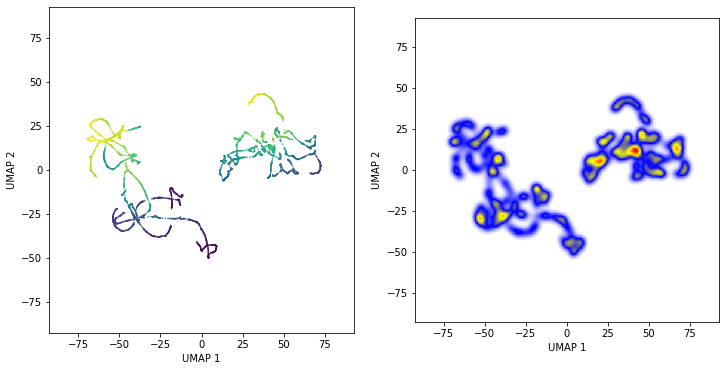

In [37]:
trainy = hdf5storage.loadmat(f'{parameters.projectPath}/{parameters.method}/training_embedding.mat')['trainingEmbedding']
m = np.abs(trainy).max()

sigma=2.0
_, xx, density = mmpy.findPointDensity(trainy, sigma, 511, [-m-20, m+20])

fig, axes = plt.subplots(1, 2, figsize=(12,6))
axes[0].scatter(trainy[:,0], trainy[:,1], marker='.', c=np.arange(trainy.shape[0]), s=1)
axes[0].set_xlim([-m-20, m+20])
axes[0].set_ylim([-m-20, m+20])
axes[0].set_xlabel("UMAP 1")
axes[0].set_ylabel("UMAP 2")
axes[1].set_xlabel("UMAP 1")
axes[1].set_ylabel("UMAP 2")
axes[1].imshow(density, cmap=mmpy.gencmap(), extent=(xx[0], xx[-1], xx[0], xx[-1]), origin='lower')

# 5.&nbsp; Finding embeddings for all data

UMAP for all data

In [38]:
tall = time.time()

import h5py
tfolder = parameters.projectPath+'/%s/'%parameters.method

# Loading training data
with h5py.File(tfolder + 'training_data.mat', 'r') as hfile:
    trainingSetData = hfile['trainingSetData'][:].T

# Loading training embedding
with h5py.File(tfolder+ 'training_embedding.mat', 'r') as hfile:
    trainingEmbedding= hfile['trainingEmbedding'][:].T

if parameters.method == 'TSNE':
    zValstr = 'zVals'
else:
    zValstr = 'uVals'

projectionFiles = glob.glob(parameters.projectPath+'/Projections/*pcaModes.mat')
for i in range(len(projectionFiles)):
    print('Finding Embeddings')
    t1 = time.time()
    print(f'{i+1}/{len(projectionFiles)} : {projectionFiles[i]}')

    # Skip if embeddings already found.
    if os.path.exists(projectionFiles[i][:-4] +f'_{zValstr}.mat'):
        print('Already done. Skipping.\n')
        continue

    # load projections for a dataset
    projections = hdf5storage.loadmat(projectionFiles[i])['projections']

    # Find Embeddings
    zValues, outputStatistics = mmpy.findEmbeddings(projections,trainingSetData,trainingEmbedding,parameters)

    # Save embeddings
    hdf5storage.write(data = {'zValues':zValues}, path = '/', truncate_existing = True,
                    filename = projectionFiles[i][:-4]+f'_{zValstr}.mat', store_python_metadata = False,
                      matlab_compatible = True)

    # Save output statistics
    with open(projectionFiles[i][:-4] + f'_{zValstr}_outputStatistics.pkl', 'wb') as hfile:
        pickle.dump(outputStatistics, hfile)

    del zValues,projections,outputStatistics

print(f'All Embeddings Saved in {time.time()-tall} seconds!')


Finding Embeddings
1/1 : /Users/cyrilmonette/Desktop/EPFL 2018-2026/PhD - Mobots/PdS/(25b) Ethograms/Ethogram-Generation/Results/WideNormalisation/Projections/observation_OH_pcaModes.mat
Finding Wavelets
	 Calculating wavelets, clock starting.
	 Using #12 CPUs.
	 Done at 0.73 seconds.
Finding Embeddings
	Loading UMAP Model.
	Loaded.
Embeddings found in 7.57 seconds.
All Embeddings Saved in 8.459656238555908 seconds!


Visualisation of Density Map

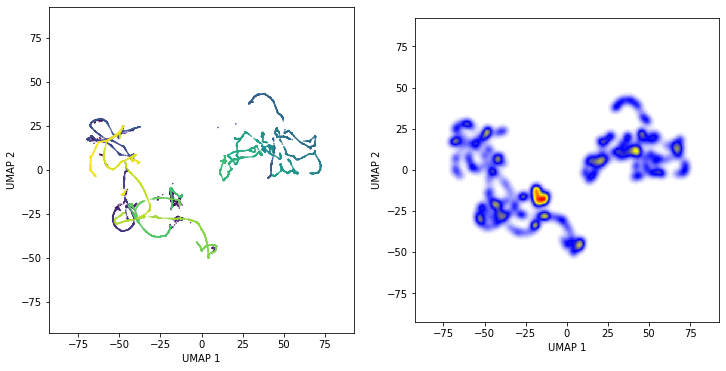

In [39]:
# load all the embeddings
for i in glob.glob(parameters.projectPath+f'/Projections/*_{zValstr}.mat'):
  ally = hdf5storage.loadmat(i)['zValues']

m = np.abs(ally).max()

sigma=2.0
_, xx, density = mmpy.findPointDensity(ally, sigma, 511, [-m-20, m+20])


fig, axes = plt.subplots(1, 2, figsize=(12,6))
axes[0].scatter(ally[:,0], ally[:,1], marker='.', c=np.arange(ally.shape[0]), s=1)
axes[0].set_xlim([-m-20, m+20])
axes[0].set_ylim([-m-20, m+20])
axes[0].set_xlabel("UMAP 1")
axes[0].set_ylabel("UMAP 2")
axes[1].set_xlabel("UMAP 1")
axes[1].set_ylabel("UMAP 2")
axes[1].imshow(density, cmap=mmpy.gencmap(), extent=(xx[0], xx[-1], xx[0], xx[-1]), origin='lower')

# 6.&nbsp; Watershed transform on the density map.

In [40]:
# Parameter for Watershed
min_regions = 10

1/1 Loading embedding for observation_OH_pcaModes 0.00 seconds.
Starting watershed transform...
Assigning watershed regions...
	 tempsave done.
All data saved in UMAP/zVals_wShed_groups.mat.


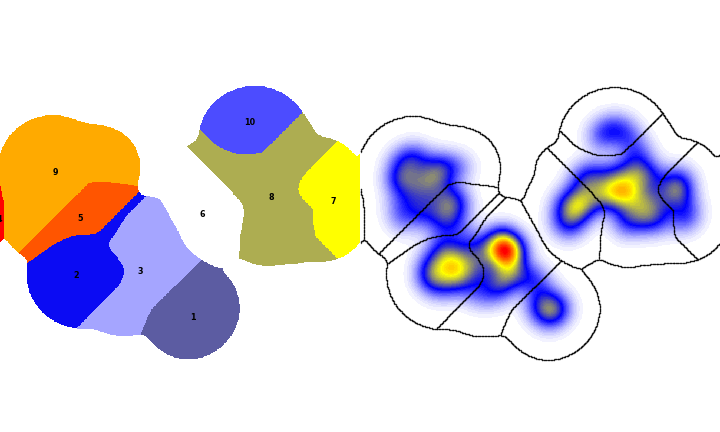

In [41]:
startsigma = 1.0 if parameters.method == 'TSNE' else 1.0
mmpy.findWatershedRegions(parameters, minimum_regions=min_regions, startsigma=startsigma, pThreshold=[0.33, 0.67], saveplot=True, endident = '*_pcaModes.mat')

from IPython.display import Image
Image(glob.glob(f'{parameters.projectPath}/{parameters.method}/zWshed*.png')[0])

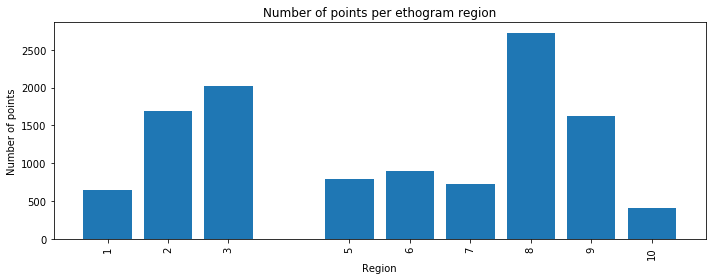

In [42]:
# wregs : 1D array containing the region label for each point (0 = background, 1..K = regions)
wshedfile = hdf5storage.loadmat(f'{parameters.projectPath}/{parameters.method}/zVals_wShed_groups.mat')
wregs = wshedfile['watershedRegions'].flatten().astype(int)
unique, counts = np.unique(wregs, return_counts=True)

# Put in DataFrame format for easier reading
df_counts = pd.DataFrame({
    "region": unique.astype(int),
    "n_points": counts.astype(int)
})

fig, ax = plt.subplots(figsize=(10, 4))

ax.bar(df_counts["region"], df_counts["n_points"])

ax.set_xlabel("Region")
ax.set_ylabel("Number of points")
ax.set_title("Number of points per ethogram region")

ax.set_xticks(df_counts["region"])
ax.tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()


# 7.&nbsp; Ethogram Interpretation Tools

## Region Timeline


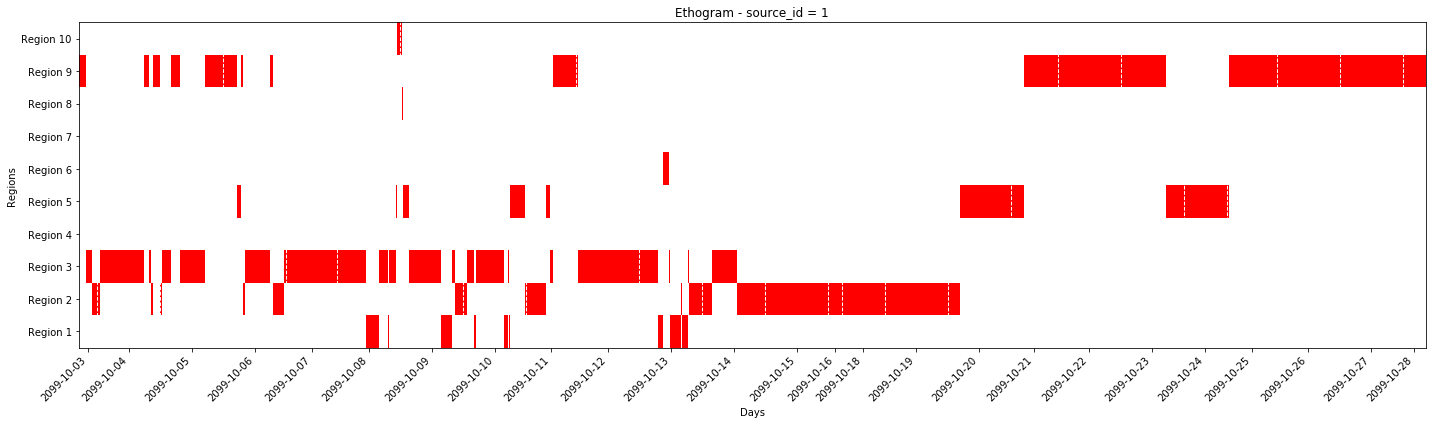

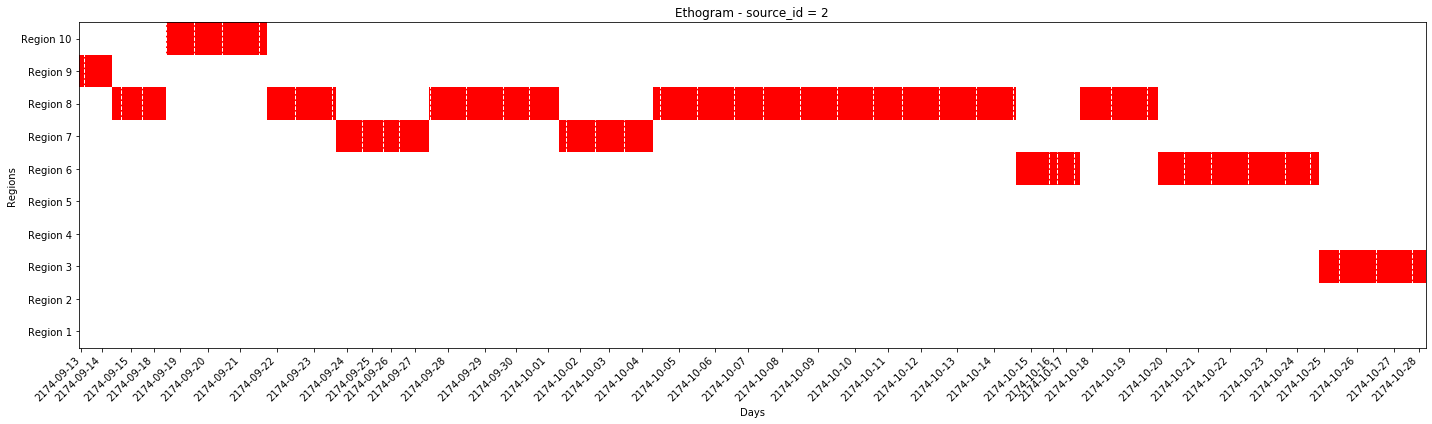

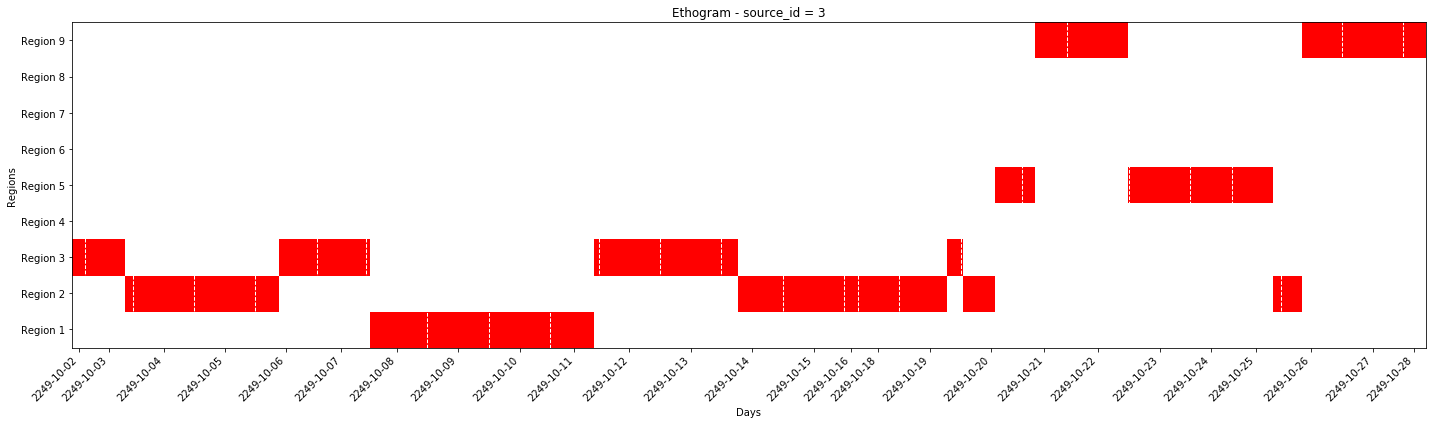

In [43]:
from utils import build_ethogram, day_boundaries_from_df, plot_ethogram, get_source_vector

# --- Load wregs (same order as df_concat) ---
wshedfile = hdf5storage.loadmat(f'{parameters.projectPath}/{parameters.method}/zVals_wShed_groups.mat')
wregs = wshedfile['watershedRegions'].flatten().astype(int)
assert len(wregs) == len(df_concat), "wregs et df_concat doivent avoir même longueur et ordre."

# --- Save source_id vector ---
src = get_source_vector(df_concat)

# --- MultiIndex (timestamp, source_id) no reordering ---
if not (isinstance(df_concat.index, pd.MultiIndex) and 'source_id' in df_concat.index.names):
    if 'source_id' in df_concat.columns:
        df_concat = df_concat.set_index('source_id', append=True)  # aucun tri !
        df_concat.index = df_concat.index.set_names(['timestamp','source_id'])
    else:
        raise KeyError("Impossible to create the MultiIndex: 'source_id' is not in columns.")

# --- Iterates on sources (1,2,3) ---
for sid in sorted(pd.unique(src)):
    mask = (src == sid)
    if not mask.any():
        continue

    df_s = df_concat[mask]
    w_s  = wregs[mask]

    # Build & plot
    E, nreg = build_ethogram(w_s)
    dnames, bounds, nperday = day_boundaries_from_df(df_s)
    plot_ethogram(E, nreg, dnames, bounds, nperday, title=f"Ethogram - source_id = {sid}")

## Plot 100 points around barycentre

In [44]:
# Verify alignment
assert len(df_nat) == len(wregs), "df_concat et wregs doivent avoir la même longueur."

# 1) Add regions as column
df_regions = df_nat.copy()
df_regions["region"] = wregs

# Add UMAP coords
rounded_ally = [[round(x,2) for x in row] for row in ally]
df_regions["UMAP"] = rounded_ally

df_regions.head()

,t00,t01,t02,t03,t04,t05,t06,t07,t08,t09,t10,t11,t12,t13,t14,t15,t16,t17,t18,t19,t20,t21,t22,t23,t24,t25,t26,t27,t28,t29,t30,t31,t32,t33,t34,t35,t36,t37,t38,t39,t40,t41,t42,t43,t44,t45,t46,t47,t48,t49,t50,t51,t52,t53,t54,t55,t56,t57,t58,t59,t60,t61,t62,t63,co2_L,co2_R,rel_humid,real_timestamp,source_id,region,UMAP
datetime,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2099-10-03 17:00:00+00:00,19.960938,19.679688,19.640625,19.734375,19.773438,20.039062,21.007812,20.484375,19.945312,20.164062,19.929688,19.773438,20.898438,21.289062,20.156250,19.867188,20.054688,19.835938,19.960938,20.226562,20.101562,19.812500,20.007812,20.281250,19.882812,20.109375,20.875000,20.929688,20.062500,20.312500,20.296875,20.039062,20.187500,20.125000,20.148438,20.062500,20.062500,20.023438,20.007812,20.046875,20.531250,19.906250,19.851562,20.007812,19.976562,19.718750,19.742188,20.054688,19.640625,19.796875,20.015625,20.140625,19.531250,19.742188,19.867188,19.632812,19.476562,19.726562,19.578125,19.460938,19.632812,19.375000,19.304688,19.335938,2258,776,62.863193,2024-10-03 17:00:00+00:00,1,9,"[-47.6, 24.62]"
2099-10-03 17:10:00+00:00,19.992188,19.710938,19.664062,19.757812,19.804688,20.078125,21.046875,20.523438,19.976562,20.187500,19.960938,19.804688,20.937500,21.335938,20.195312,19.906250,20.109375,19.890625,19.992188,20.250000,20.148438,19.859375,20.039062,20.289062,19.921875,20.164062,20.914062,20.976562,20.093750,20.296875,20.304688,20.062500,20.234375,20.171875,20.195312,20.117188,20.117188,20.078125,20.062500,20.101562,20.578125,19.953125,19.890625,20.054688,19.992188,19.773438,19.796875,20.093750,19.687500,19.820312,20.031250,20.132812,19.570312,19.773438,19.906250,19.687500,19.484375,19.726562,19.593750,19.500000,19.648438,19.414062,19.335938,19.359375,1945,821,63.293373,2024-10-03 17:10:00+00:00,1,9,"[-47.69, 24.59]"
2099-10-03 17:20:00+00:00,20.039062,19.757812,19.734375,19.812500,19.859375,20.117188,21.085938,20.562500,20.015625,20.203125,20.000000,19.867188,20.984375,21.382812,20.242188,19.968750,20.164062,19.960938,20.039062,20.281250,20.203125,19.921875,20.078125,20.312500,19.953125,20.210938,20.960938,21.023438,20.117188,20.335938,20.335938,20.101562,20.281250,20.218750,20.234375,20.164062,20.171875,20.125000,20.101562,20.148438,20.617188,20.000000,19.921875,20.101562,20.007812,19.796875,19.835938,20.132812,19.710938,19.851562,20.031250,20.156250,19.609375,19.812500,19.937500,19.718750,19.523438,19.742188,19.617188,19.531250,19.687500,19.460938,19.390625,19.398438,2111,1250,64.430927,2024-10-03 17:20:00+00:00,1,9,"[-47.68, 24.54]"
2099-10-03 17:30:00+00:00,20.062500,19.789062,19.765625,19.867188,19.898438,20.156250,21.125000,20.585938,20.054688,20.203125,20.046875,19.914062,21.023438,21.445312,20.312500,20.023438,20.226562,20.007812,20.078125,20.289062,20.242188,19.945312,20.117188,20.328125,19.976562,20.242188,21.000000,21.039062,20.117188,20.335938,20.351562,20.125000,20.320312,20.257812,20.273438,20.195312,20.203125,20.156250,20.140625,20.179688,20.648438,20.023438,19.929688,20.132812,20.015625,19.812500,19.867188,20.164062,19.742188,19.867188,20.046875,20.164062,19.640625,19.843750,19.976562,19.757812,19.515625,19.757812,19.625000,19.539062,19.703125,19.484375,19.398438,19.406250,2131,942,62.922513,2024-10-03 17:30:00+00:00,1,9,"[-47.67, 24.55]"
2099-10-03 17:40:00+00:00,20.125000,19.843750,19.828125,19.898438,19.976562,20.218750,21.156250,20.617188,20.109375,20.250000,20.093750,19.984375,21.078125,21.460938,20.351562,20.078125,20.265625,20.046875,20.109375,20.289062,20.289062,19.992188,20.132812,20.335938,20.015625,20.273438,21.046875,21.078125,20.132812,20.343750,20.351562,20.132812,20.351562,20.289062,20.312500,20.226562,20.234375,20.187500,20.171875,20.218750,20.695312,20.062500,19.945312,20.164062,20.023438,19.835938,19.914062,20.203125,19.750000,19.882812,20.062500,20.171875,19.664062,19.882812,20.007812,19.789062,19.515625,19.765625,19.656250,19.578125,19.757812,19.531250,19.429688,19.437500,2859,1

Compute Barycenters

In [45]:
rounded_ally = np.round(ally, decimals=2)
assert len(rounded_ally) == len(wregs)

region_ids = np.unique(wregs)

barycenters = {}  # dict: region_id -> (x_mean, y_mean)

for rid in region_ids:
    if rid == 0:
        # Ignore region 0 if it is the backgound
        continue
    
    mask = (wregs == rid)
    if not np.any(mask):
        continue 

    pts = rounded_ally[mask]      # shape (n_points_region, 2)
    center = pts.mean(axis=0)     # shape (2,)

    barycenters[int(rid)] = (float(center[0]), float(center[1]))

print(barycenters)


{1: (4.235304355621338, -43.76972961425781), 2: (-42.89892578125, -24.514389038085938), 3: (-17.435386657714844, -22.110069274902344), 5: (-46.30888748168945, 3.091440439224243), 6: (17.533676147460938, 3.580615282058716), 7: (67.90816497802734, 9.35743236541748), 8: (42.81189727783203, 12.308903694152832), 9: (-58.13043212890625, 17.70755386352539), 10: (36.28639602661133, 40.60072708129883)}


Compute the 100 nearest points to the barycenters

In [46]:
closest_per_region = {}  # dict : region_id -> DataFrame of the 100 nearest points

for rid, center in barycenters.items():
    cx, cy = center

    # subset of the region
    sub = df_regions[df_regions["region"] == rid].copy()
    if sub.empty:
        continue

    # distance calculation function
    def dist_to_center(umap_xy):
        x, y = umap_xy
        return np.sqrt((x - cx)**2 + (y - cy)**2)

    sub["dist_to_center"] = sub["UMAP"].apply(dist_to_center)

    # Take the closest 100 points
    closest_per_region[rid] = sub.sort_values("dist_to_center").head(100)


Temperature Plot

Temperature columns : ['t00', 't01', 't02', 't03', 't04', 't05', 't06', 't07', 't08', 't09', 't10', 't11', 't12', 't13', 't14', 't15', 't16', 't17', 't18', 't19', 't20', 't21', 't22', 't23', 't24', 't25', 't26', 't27', 't28', 't29', 't30', 't31', 't32', 't33', 't34', 't35', 't36', 't37', 't38', 't39', 't40', 't41', 't42', 't43', 't44', 't45', 't46', 't47', 't48', 't49', 't50', 't51', 't52', 't53', 't54', 't55', 't56', 't57', 't58', 't59', 't60', 't61', 't62', 't63']
Global temp Y-limits: 13.2109375 35.71875


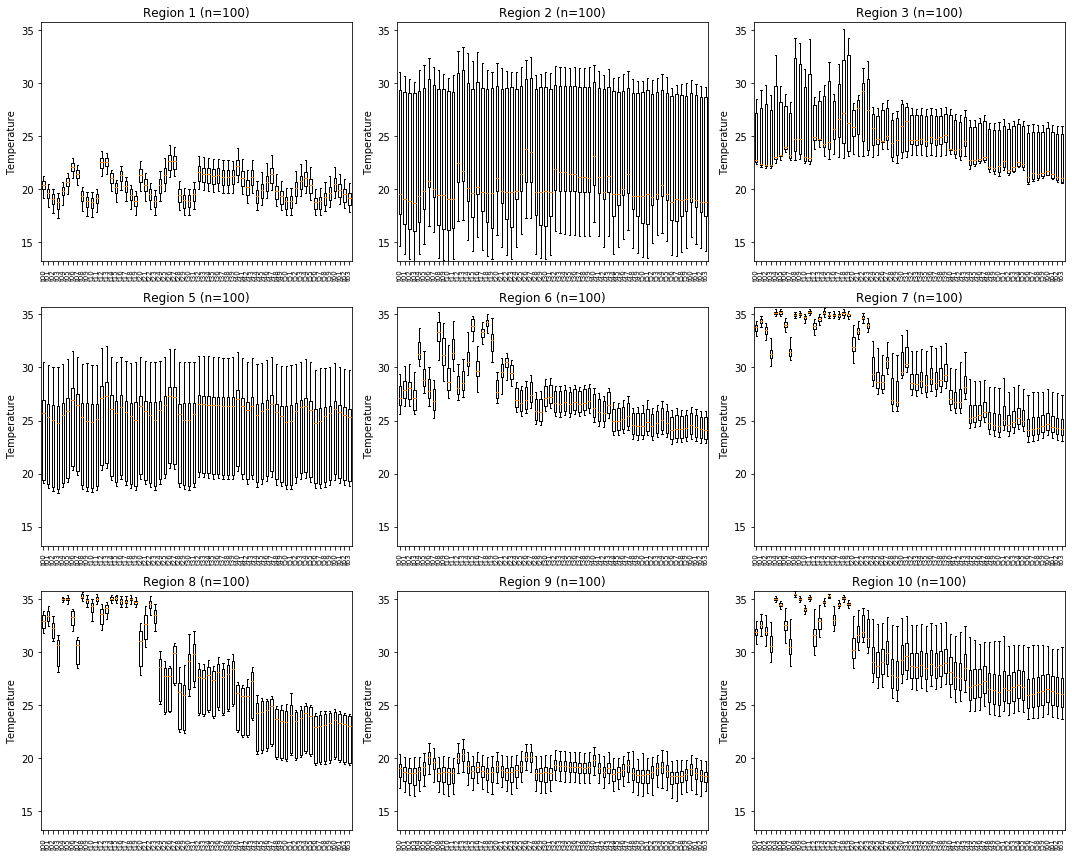

In [47]:
# 1) Detection of temperature columns
sample_df = next(iter(closest_per_region.values()))
temp_cols = [c for c in sample_df.columns if c.startswith("t") and c[1:].isdigit()]
print("Temperature columns :", temp_cols)

# 2) Find global min/max temperatures across all regions
all_temp_vals = []

for rid, df_r in closest_per_region.items():
    for c in temp_cols:
        if c in df_r.columns:
            vals = df_r[c].dropna().values
            if len(vals) > 0:
                all_temp_vals.extend(vals)

if not all_temp_vals:
    raise ValueError("No temperature values found in closest_per_region.")

global_min = min(all_temp_vals)
global_max = max(all_temp_vals)
print("Global temp Y-limits:", global_min, global_max)

# 3) Layout of subplots
region_ids = sorted(closest_per_region.keys())
n_regions = len(region_ids)

ncols = min(3, n_regions)
nrows = int(np.ceil(n_regions / ncols))

fig, axes = plt.subplots(
    nrows=nrows, ncols=ncols,
    figsize=(5*ncols, 4*nrows),
    squeeze=False
)

# 4) Plot per region
for ax, rid in zip(axes.flatten(), region_ids):
    df_r = closest_per_region[rid]

    # extraire les données de température
    data = [df_r[c].dropna().values for c in temp_cols]

    ax.boxplot(
        data,
        showfliers=False,
        widths=0.5
    )

    ax.set_title(f"Region {rid} (n={len(df_r)})")
    ax.set_xticks(range(1, len(temp_cols) + 1))
    ax.set_xticklabels(temp_cols, rotation=90, fontsize=7)
    ax.set_ylabel("Temperature")

    # Same scale for y-axis
    ax.set_ylim(global_min, global_max)

# Delete empty axes if needed
for i in range(len(region_ids), nrows * ncols):
    fig.delaxes(axes.flatten()[i])

plt.tight_layout()
plt.show()

CO2 Plot

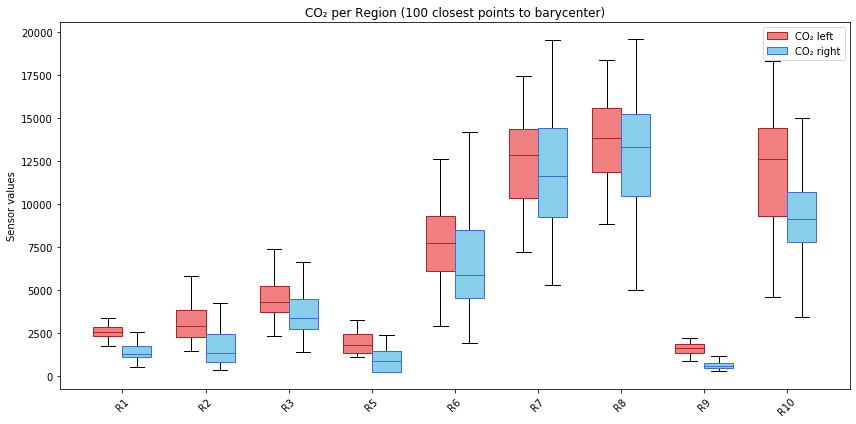

In [59]:
region_ids = sorted(closest_per_region.keys())
co2_data_right = []
co2_data_left = []
labels = []

for rid in region_ids:
    df_r = closest_per_region[rid]

    if "co2_R" in df_r.columns:
        co2_data_right.append(df_r["co2_R"].dropna().values)
    else:
        co2_data_right.append([np.nan])

    if "co2_L" in df_r.columns:
        co2_data_left.append(df_r["co2_L"].dropna().values)
    else:
        co2_data_left.append([np.nan])

    labels.append(f"R{rid}")

x = np.arange(len(region_ids))

fig, ax = plt.subplots(figsize=(12, 6))

w = 0.35
offset = w / 2.0

# boxplots CO2
bp_left = ax.boxplot(
    co2_data_left,
    positions=x - offset,
    widths=w,
    patch_artist=True,
    boxprops=dict(facecolor="lightcoral", edgecolor="firebrick"),
    medianprops=dict(color="firebrick"),
    showfliers=False
)
bp_right = ax.boxplot(
    co2_data_right,
    positions=x + offset,
    widths=w,
    patch_artist=True,
    boxprops=dict(facecolor="skyblue", edgecolor="royalblue"),
    medianprops=dict(color="royalblue"),
    showfliers=False
)

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45)
ax.set_xlim(-0.75, len(region_ids) - 0.25)
ax.set_ylabel("Sensor values")
ax.set_title("CO₂ per Region (100 closest points to barycenter)")

ax.legend([bp_left["boxes"][0], bp_right["boxes"][0]], ["CO₂ left", "CO₂ right"])

plt.tight_layout()
plt.show()

Humidity Plot

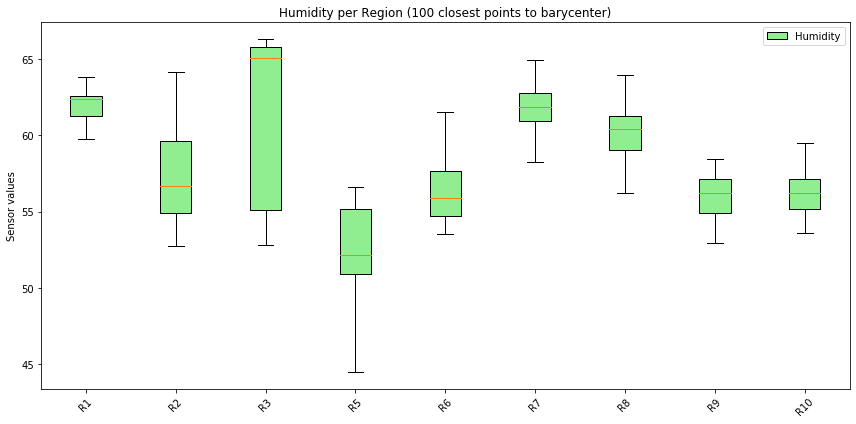

In [78]:
region_ids = sorted(closest_per_region.keys())

hum_data = []
labels = []

for rid in region_ids:
    df_r = closest_per_region[rid]

    if "rel_humid" in df_r.columns:
        hum_data.append(df_r["rel_humid"].dropna().values)
    else:
        hum_data.append([np.nan])
    
    labels.append(f"R{rid}")

x = np.arange(len(region_ids))

fig, ax = plt.subplots(figsize=(12, 6))

# boxplots Humidité
bp2 = ax.boxplot(
    hum_data,
    positions=x,
    widths=w,
    patch_artist=True,
    boxprops=dict(facecolor="lightgreen"),
    showfliers=False
)

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45)
ax.set_ylabel("Sensor values")
ax.set_title("Humidity per Region (100 closest points to barycenter)")

ax.legend([bp2["boxes"][0]], ["Humidity"])

plt.tight_layout()
plt.show()

Day/Night Count

Region 1: day=18, night=82, total=100
Region 2: day=72, night=28, total=100
Region 3: day=65, night=35, total=100
Region 5: day=20, night=80, total=100
Region 6: day=35, night=65, total=100
Region 7: day=42, night=58, total=100
Region 8: day=53, night=47, total=100
Region 9: day=6, night=94, total=100
Region 10: day=37, night=63, total=100


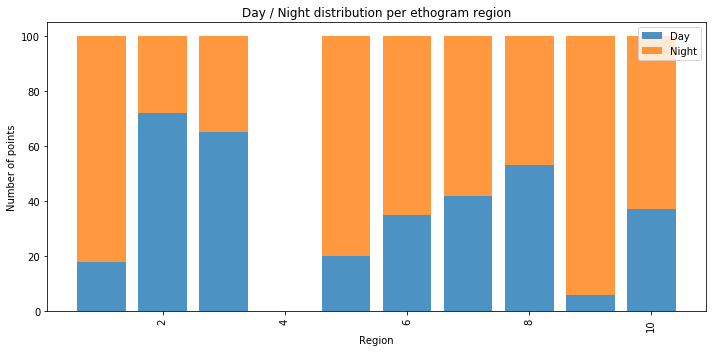

In [79]:
def is_day(ts):
    """Jour = 08:00 → 20:00 (inclus 8h, exclu 20h)"""
    hour = ts.hour
    return 8 <= hour < 20

day_night_counts = {}

for rid, df_r in closest_per_region.items():

    # --- Selest timestamp according to index type ---
    if isinstance(df_r.index, pd.MultiIndex):
        ts = df_r.index.get_level_values("timestamp")
    else:
        ts = df_r.index

    ts = pd.to_datetime(ts)

    # Series to allow .map()
    ts_series = pd.Series(ts)

    # day / night
    is_day_mask = ts_series.map(is_day).astype(bool)

    n_day = int(is_day_mask.sum())
    total = len(ts_series)
    n_night = int(total - n_day)

    day_night_counts[rid] = {
        "day": n_day,
        "night": n_night,
        "total": total
    }

# Print
for rid, c in day_night_counts.items():
    print(f"Region {rid}: day={c['day']}, night={c['night']}, total={c['total']}")
    
df_day_night = (
    pd.DataFrame.from_dict(day_night_counts, orient="index")
    .reset_index()
    .rename(columns={"index": "region"})
    .sort_values("region")
)

# Plot 

fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(
    df_day_night["region"],
    df_day_night["day"],
    label="Day",
    alpha=0.8
)

ax.bar(
    df_day_night["region"],
    df_day_night["night"],
    bottom=df_day_night["day"],
    label="Night",
    alpha=0.8
)

ax.set_xlabel("Region")
ax.set_ylabel("Number of points")
ax.set_title("Day / Night distribution per ethogram region")

ax.legend()
ax.tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()

## Plot 10 points around barycentre

In [80]:
k = 10
rows = []

for region_id, bary in barycenters.items():
    df_r = df_regions[df_regions["region"] == region_id]
    if df_r.empty:
        continue

    coords = np.vstack(df_r["UMAP"].values).astype(float)
    dists = np.linalg.norm(coords - np.asarray(bary, dtype=float), axis=1)

    # index of the k nearest points
    k_eff = min(k, len(df_r))
    idx_topk = np.argsort(dists)[:k_eff]

    for rank, idx in enumerate(idx_topk, start=1):
        row = df_r.iloc[idx]

        real_ts = pd.to_datetime(row["real_timestamp"]) if "real_timestamp" in df_r.columns else pd.to_datetime(df_r.index[idx])
        source_id = row["source_id"] if "source_id" in df_r.columns else None

        row_dict = {
            "region": int(region_id),
            "rank": int(rank),                
            "distance": float(dists[idx]),
            "real_timestamp": real_ts,
            "source_id": source_id,
        }
        
        # copy all other useful columns (sensors, etc.), except UMAP and regioon
        for col in df_regions.columns:
            if col not in ["UMAP", "region"]:
                row_dict[col] = row[col]

        rows.append(row_dict)

df_region_top5 = (
    pd.DataFrame(rows)
    .set_index(["region", "rank"])
    .sort_index()
)

#df_region_top5.head(30)


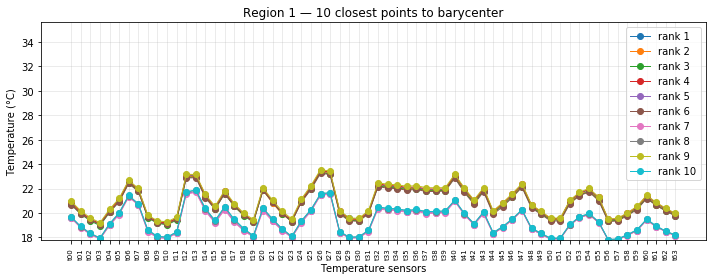

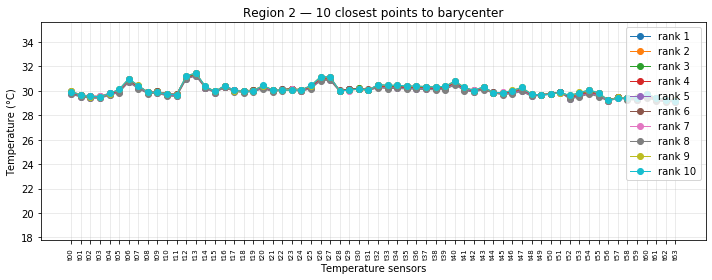

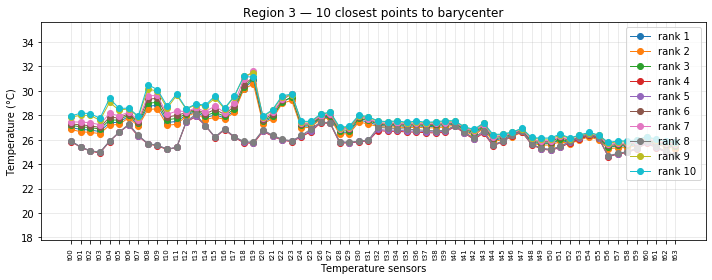

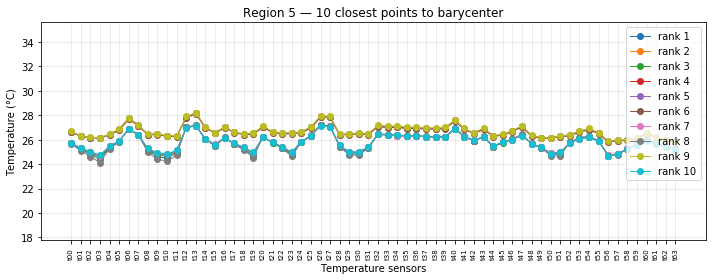

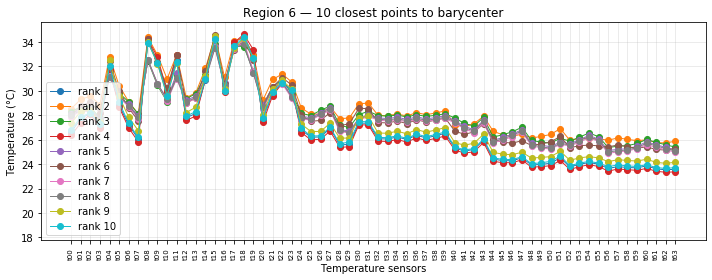

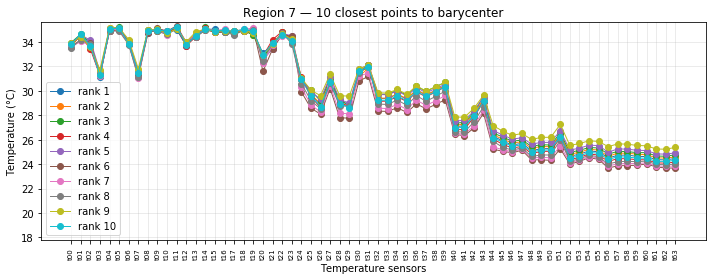

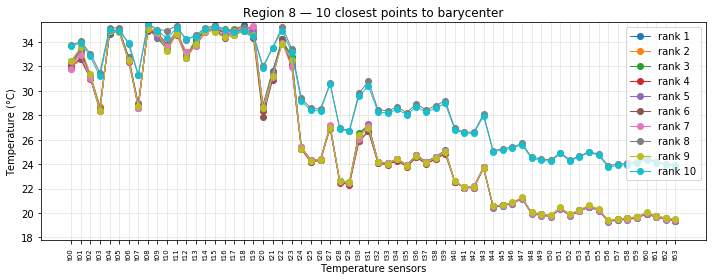

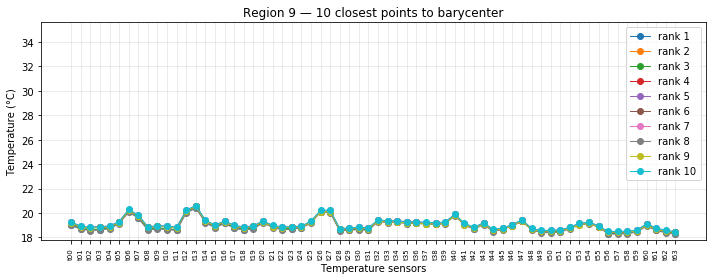

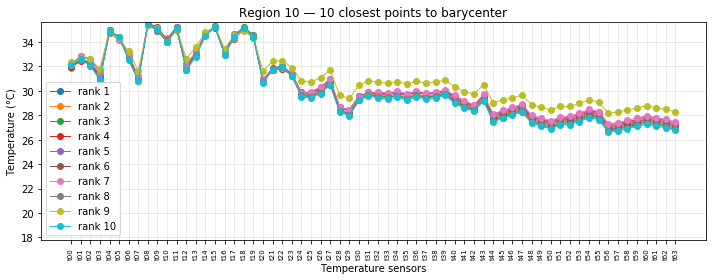

In [81]:
# temp columns
temp_cols = [c for c in df_regions.columns if c.startswith("t") and c[1:].isdigit()]
temp_cols = sorted(temp_cols)

# same scale
ymin = df_region_top5[temp_cols].min().min()
ymax = df_region_top5[temp_cols].max().max()

x = np.arange(len(temp_cols))

for region_id in df_region_top5.index.get_level_values("region").unique():

    df_r5 = df_region_top5.loc[region_id]   # index = rank (1..5)

    plt.figure(figsize=(10, 4))

    for rank, row in df_r5.iterrows():
        temps = row[temp_cols].values.astype(float)
        plt.plot(x, temps, marker='o', linewidth=1, label=f"rank {rank}")

    plt.xticks(x, temp_cols, rotation=90, fontsize=7)
    plt.ylim(ymin, ymax)

    plt.xlabel("Temperature sensors")
    plt.ylabel("Temperature (°C)")
    plt.title(f"Region {region_id} — 10 closest points to barycenter")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()


# 8. Model Robustness

First, we create a profile using the 10 most representative points of region 7

In [82]:
region_id = 7

df_r7 = df_region_top5.loc[region_id]

if isinstance(df_r7, pd.Series):
    df_r7 = df_r7.to_frame().T

# sécurité
assert len(df_r7) >= 10, "Pas assez de points pour la région 7"

df_r7_10 = df_r7.iloc[:10]

Build region 7 profile

In [83]:
temp_cols = [c for c in df_r7_10.columns if c.startswith("t")]
temp_cols = sorted(temp_cols)  # t00 → t63
co2_col_L = "co2_L"
co2_col_R = "co2_R"
humid_col = "rel_humid"

profile_mean = {}

# temperatures
for c in temp_cols:
    profile_mean[c] = df_r7_10[c].mean()

# co2 & humidity
profile_mean[co2_col_L] = df_r7_10[co2_col_L].mean()
profile_mean[co2_col_R] = df_r7_10[co2_col_R].mean()
profile_mean[humid_col] = df_r7_10[humid_col].mean()

Inverse temperature sensors order

In [84]:
temp_values = [profile_mean[c] for c in temp_cols]
temp_values_inverted = temp_values[::-1]

profile_inverted = {}

for c, v in zip(temp_cols, temp_values_inverted):
    profile_inverted[c] = v

# co2 & humidité inchangés
profile_inverted[co2_col_L] = profile_mean[co2_col_L]
profile_inverted[co2_col_R] = profile_mean[co2_col_R]
profile_inverted[humid_col] = profile_mean[humid_col]


Now we generate 12 hours of data

In [85]:
n_points = 12 * 6  # 72
freq = "10min"

start_ts = pd.Timestamp("2024-01-01 00:00:00", tz="UTC")
timestamps = pd.date_range(start=start_ts, periods=n_points, freq=freq)
rows = []

for ts in timestamps:
    row = {"timestamp": ts}
    row.update(profile_inverted)
    rows.append(row)

df_fake_12h = (
    pd.DataFrame(rows)
    .set_index("timestamp")
)

print(df_fake_12h.shape)
df_fake_12h.head()

(72, 67)


,t00,t01,t02,t03,t04,t05,t06,t07,t08,t09,t10,t11,t12,t13,t14,t15,t16,t17,t18,t19,t20,t21,t22,t23,t24,t25,t26,t27,t28,t29,t30,t31,t32,t33,t34,t35,t36,t37,t38,t39,t40,t41,t42,t43,t44,t45,t46,t47,t48,t49,t50,t51,t52,t53,t54,t55,t56,t57,t58,t59,t60,t61,t62,t63,co2_L,co2_R,rel_humid
timestamp,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2024-01-01 00:00:00+00:00,24.41875,24.332031,24.361719,24.621094,24.610937,24.676562,24.678906,24.457812,25.003906,25.083594,24.817969,24.634375,26.252344,25.208594,25.215625,25.091406,25.700781,25.547656,25.828906,26.19375,29.085938,27.869531,27.0625,27.038281,30.242969,29.838281,29.471094,29.89375,29.146875,29.552344,29.21875,29.229688,31.909375,31.439062,28.715625,28.889844,30.813281,28.8125,29.524219,30.778125,34.198437,34.692969,33.774219,32.646094,34.86875,34.945312,34.832031,34.908594,34.882031,35.084375,34.538281,33.889063,35.169531,34.759375,34.996875,34.891406,31.384375,33.941406,35.084375,35.032812,31.351562,33.782812,34.432031,33.757031,15183.3,15513.2,63.105555
2024-01-01 00:10:00+00:00,24.41875,24.332031,24.361719,24.621094,24.610937,24.676562,24.678906,24.457812,25.003906,25.083594,24.817969,24.634375,26.252344,25.208594,25.215625,25.091406,25.700781,25.547656,25.828906,26.19375,29.085938,27.869531,27.0625,27.038281,30.242969,29.838281,29.471094,29.89375,29.146875,29.552344,29.21875,29.229688,31.909375,31.439062,28.715625,28.889844,30.813281,28.8125,29.524219,30.778125,34.198437,34.692969,33.774219,32.646094,34.86875,34.945312,34.832031,34.908594,34.882031,35.084375,34.538281,33.889063,35.169531,34.759375,34.996875,34.891406,31.384375,33.941406,35.084375,35.032812,31.351562,33.782812,34.432031,33.757031,15183.3,15513.2,63.105555
2024-01-01 00:20:00+00:00,24.41875,24.332031,24.361719,24.621094,24.610937,24.676562,24.678906,24.457812,25.003906,25.083594,24.817969,24.634375,26.252344,25.208594,25.215625,25.091406,25.700781,25.547656,25.828906,26.19375,29.085938,27.869531,27.0625,27.038281,30.242969,29.838281,29.471094,29.89375,29.146875,29.552344,29.21875,29.229688,31.909375,31.439062,28.715625,28.889844,30.813281,28.8125,29.524219,30.778125,34.198437,34.692969,33.774219,32.646094,34.86875,34.945312,34.832031,34.908594,34.882031,35.084375,34.538281,33.889063,35.169531,34.759375,34.996875,34.891406,31.384375,33.941406,35.084375,35.032812,31.351562,33.782812,34.432031,33.757031,15183.3,15513.2,63.105555
2024-01-01 00:30:00+00:00,24.41875,24.332031,24.361719,24.621094,24.610937,24.676562,24.678906,24.457812,25.003906,25.083594,24.817969,24.634375,26.252344,25.208594,25.215625,25.091406,25.700781,25.547656,25.828906,26.19375,29.085938,27.869531,27.0625,27.038281,30.242969,29.838281,29.471094,29.89375,29.146875,29.552344,29.21875,29.229688,31.909375,31.439062,28.715625,28.889844,30.813281,28.8125,29.524219,30.778125,34.198437,34.692969,33.774219,32.646094,34.86875,34.945312,34.832031,34.908594,34.882031,35.084375,34.538281,33.889063,35.169531,34.759375,34.996875,34.891406,31.384375,33.941406,35.084375,35.032812,31.351562,33.782812,34.432031,33.757031,15183.3,15513.2,63.105555
2024-01-01 00:40:00+00:00,24.41875,24.332031,24.361719,24.621094,24.610937,24.676562,24.678906,24.457812,25.003906,25.083594,24.817969,24.634375,26.252344,25.208594,25.215625,25.091406,25.700781,25.547656,25.828906,26.19375,29.085938,27.869531,27.0625,27.038281,30.242969,29.838281,29.471094,29.89375,29.146875,29.552344,29.21875,29.229688,31.909375,31.439062,28.715625,28.889844,30.813281,28.8125,29.524219,30.778125,34.198437,34.692969,33.774219,32.646094,34.86875,34.945312,34.832031,34.908594,34.882031,35.084375,34.538281,33.889063,35.169531,34.759375,34.996875,34.891406,31.384375,33.941406,35.084375,35.032812,31.351562,33.782812,34.432031,33.757031,15183.3,15513.2,63.105555


We add some noise to the fake data

In [86]:
def add_sensor_noise(df,
                     temp_sigma=0.2,
                     co2_sigma=100,
                     humid_sigma=0.8,
                     seed=42):
    rng = np.random.default_rng(seed)
    df_noisy = df.copy()

    # Température
    df_noisy[temp_cols] += rng.normal(0, temp_sigma, size=(len(df), len(temp_cols)))

    # CO2
    df_noisy[co2_col_L] += rng.normal(0, co2_sigma, size=len(df))
    df_noisy[co2_col_R] += rng.normal(0, co2_sigma, size=len(df))

    # Humidité
    df_noisy[humid_col] += rng.normal(0, humid_sigma, size=len(df))

    return df_noisy

In [87]:
df_fake_12h_noisy = add_sensor_noise(df_fake_12h)
df_fake_12h_noisy.head()

,t00,t01,t02,t03,t04,t05,t06,t07,t08,t09,t10,t11,t12,t13,t14,t15,t16,t17,t18,t19,t20,t21,t22,t23,t24,t25,t26,t27,t28,t29,t30,t31,t32,t33,t34,t35,t36,t37,t38,t39,t40,t41,t42,t43,t44,t45,t46,t47,t48,t49,t50,t51,t52,t53,t54,t55,t56,t57,t58,t59,t60,t61,t62,t63,co2_L,co2_R,rel_humid
timestamp,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2024-01-01 00:00:00+00:00,24.479693,24.124034,24.511809,24.809207,24.220730,24.416127,24.704474,24.394564,25.000546,24.912985,24.993848,24.789933,26.265550,25.434042,25.309127,24.919548,25.774531,25.355880,26.004596,26.183765,29.048965,27.733345,27.307008,27.007375,30.157303,29.767855,29.577556,29.966839,29.229422,29.638508,29.647080,29.148404,31.806926,31.276308,28.838821,29.115638,30.790492,28.644469,29.359323,30.908244,34.347088,34.801600,33.641117,32.692526,34.892087,34.989050,35.006317,34.953313,35.017814,35.097891,34.596105,34.015320,34.878100,34.695441,34.902800,34.763631,31.329347,34.240395,34.911209,35.226468,31.014989,33.715835,34.464582,33.874276,15069.281527,15674.611392,63.509769
2024-01-01 00:10:00+00:00,24.560995,24.490701,24.291974,24.528623,24.782533,24.638302,24.423769,24.231155,24.820016,25.183026,24.846454,24.772472,26.166893,25.240302,25.340743,25.029537,25.792136,25.415271,25.756295,26.117402,28.846770,27.966926,26.968620,27.040780,30.339118,29.927587,29.604171,29.874053,29.062215,29.536400,28.881283,28.940265,31.644835,31.239613,28.795580,28.708748,30.737649,29.072346,29.452966,30.925628,34.011714,34.651881,33.584214,32.578287,35.036812,34.599848,34.918916,34.956141,34.763201,34.795163,34.552707,33.783164,35.216066,34.763745,35.317231,34.843535,31.179676,33.977261,35.128374,35.304650,31.518585,33.854187,34.724692,33.519279,15140.088824,15523.290154,61.961957
2024-01-01 00:20:00+00:00,24.290800,24.146716,24.283757,24.345757,24.737968,24.632118,24.384745,24.254697,25.066609,25.251219,25.217315,25.217147,26.335226,25.010686,24.789216,25.144949,25.538193,25.464585,25.706487,26.165592,29.299134,27.900941,27.030773,26.831150,29.908032,29.741020,29.460337,30.247336,29.172930,29.748892,29.118891,28.992699,31.716352,31.294017,29.141319,28.725566,30.980979,28.631915,29.710533,30.855115,34.167110,34.684816,33.643261,32.735308,34.777753,34.700191,34.576444,34.943111,35.197850,35.116373,34.514554,33.946228,35.430732,34.803252,34.914690,35.112664,31.470126,34.248557,35.121022,34.787919,31.077931,34.112998,34.776764,33.721127,15193.059326,15450.877082,64.533514
2024-01-01 00:30:00+00:00,24.342113,24.624320,24.140310,24.442148,24.739603,24.597641,24.677882,24.425124,25.071421,25.365090,24.836086,24.763163,25.842309,25.198850,25.046979,24.847644,25.525151,25.480832,26.012087,25.928471,29.092064,27.772697,26.996965,27.238833,30.350592,30.105761,29.440193,29.754561,29.102103,29.600843,29.254065,29.012810,31.927473,31.484708,29.219120,29.265213,30.642633,28.755023,29.231530,30.659984,34.261559,34.934139,33.628402,32.515264,34.439292,34.912779,34.619548,34.802706,34.706659,35.065522,34.186736,33.595653,35.595381,34.501890,34.777518,35.258789,31.965388,33.707093,35.010725,35.101124,31.697302,33.585441,34.382976,33.912499,15382.398688,15451.060551,62.618475
2024-01-01 00:40:00+00:00,24.505703,24.256800,24.334954,24.346115,24.563303,24.623285,24.725340,24.346747,25.098214,25.286137,24.849055,24.704726,26.262975,25.208611,25.071313,25.154705,25.681324,25.966290,26.143577,26.270919,28.933326,27.647049,27.300729,27.090831,30.338997,29.489364,29.656581,29.984634,28.924789,29.458039,29.271493,29.240181,31.850941,31.418365,28.665230,28.920356,31.107580,28.299168,29.476849,30.813427,34.257636,34.618586,33.422874,32.711693,35.214220,34.638540,35.004797,34.842889,34.869766,34.873795,34.471390,34.149071,35.286062,35.105837,35.232357,34.979224,31.733162,34.029205,35.249973,34.973498,31.364872,33.643328,34.629948,33.521371,15141.031702,15448.287688,63.240120


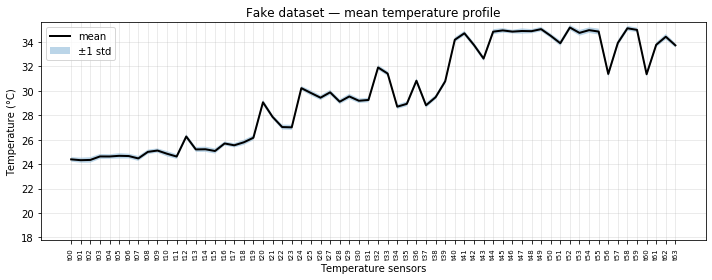

In [88]:
mean_profile = df_fake_12h_noisy[temp_cols].mean()
std_profile  = df_fake_12h_noisy[temp_cols].std()

plt.figure(figsize=(10, 4))

plt.plot(x, mean_profile, color="black", linewidth=2, label="mean")
plt.fill_between(
    x,
    mean_profile - std_profile,
    mean_profile + std_profile,
    alpha=0.3,
    label="±1 std"
)

plt.xticks(x, temp_cols, rotation=90, fontsize=7)
plt.ylim(ymin, ymax)

plt.xlabel("Temperature sensors")
plt.ylabel("Temperature (°C)")
plt.title("Fake dataset — mean temperature profile")
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

In [95]:
# Normalize & PCA transform
feature_cols = df_concat.columns
df_fake_aligned = df_fake_12h_noisy[feature_cols].copy()

if WideNormalisation:
    X_fake_scaled = df_fake_aligned.copy()
    temp_cols = [f"t{i:02d}" for i in range(64)]
    co2_cols = ["co2_L", "co2_R"]
    X_fake_scaled[temp_cols] = (df_fake_aligned[temp_cols] - temp_mean) / temp_std
    X_fake_scaled[co2_cols] = (df_fake_aligned[co2_cols] - co2_mean) / co2_std

    X_fake_pca = p.transform(X_fake_scaled)[:, :comps_above_thresh]
else:
    X_fake_scaled = scaler.transform(df_fake_aligned.values)

    X_fake_pca = p.transform(X_fake_scaled)[:, :comps_above_thresh]

UMAP Projection

Finding embedding for fake data ...
Finding Wavelets
	 Calculating wavelets, clock starting.
	 Using #12 CPUs.
	 Done at 0.25 seconds.
Finding Embeddings
	Loading UMAP Model.
	Loaded.
Embeddings found in 0.79 seconds.
Done. zValues_fake shape: (72, 2)


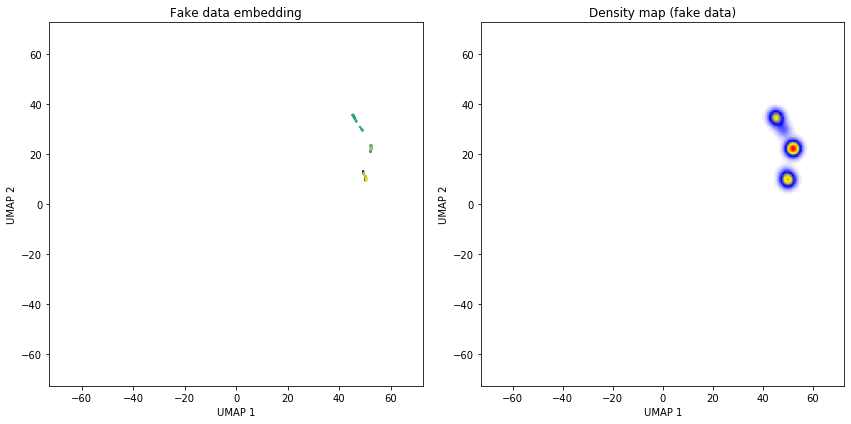

Fake embedding computed in 1.46 seconds.


In [96]:
tall = time.time()

import h5py

tfolder = parameters.projectPath + f'/{parameters.method}/'

# ----------------------------
# 1) Load training data + training embedding
# ----------------------------
with h5py.File(tfolder + 'training_data.mat', 'r') as hfile:
    trainingSetData = hfile['trainingSetData'][:].T

with h5py.File(tfolder + 'training_embedding.mat', 'r') as hfile:
    trainingEmbedding = hfile['trainingEmbedding'][:].T

# nom des zValues selon méthode
zValstr = 'zVals' if parameters.method == 'TSNE' else 'uVals'

# ----------------------------
# 2) Fake data PCA projections extraction
# ----------------------------
if hasattr(X_fake_pca, "values"):
    projections_fake = X_fake_pca.values
else:
    projections_fake = np.asarray(X_fake_pca)

# security checks
assert projections_fake.ndim == 2, "X_fake_pca doit être de dimension (N, pcaModes)."
assert projections_fake.shape[1] == parameters.pcaModes, (
    f"X_fake_pca a {projections_fake.shape[1]} colonnes mais parameters.pcaModes = {parameters.pcaModes}."
)

# ----------------------------
# 3) Embedding Calculation (uVals / zVals) for the fake data
# ----------------------------
print("Finding embedding for fake data ...")
zValues_fake, outputStatistics_fake = mmpy.findEmbeddings(
    projections_fake,
    trainingSetData,
    trainingEmbedding,
    parameters
)

print("Done. zValues_fake shape:", zValues_fake.shape)

# ----------------------------
# 4) Save as a .mat file
# ----------------------------
fake_outfile = tfolder + f'fake_{zValstr}.mat'

hdf5storage.write(
    data={'zValues': zValues_fake},
    path='/',
    truncate_existing=True,
    filename=fake_outfile,
    store_python_metadata=False,
    matlab_compatible=True
)

# ----------------------------
# 5) Scatter + density plot of the fake data
# ----------------------------
ally = zValues_fake
m = np.abs(ally).max()

sigma = 2.0
_, xx, density = mmpy.findPointDensity(ally, sigma, 511, [-m-20, m+20])

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].scatter(ally[:, 0], ally[:, 1], marker='.', c=np.arange(ally.shape[0]), s=10)
axes[0].set_xlim([-m-20, m+20])
axes[0].set_ylim([-m-20, m+20])
axes[0].set_title("Fake data embedding")
axes[0].set_xlabel("UMAP 1")
axes[0].set_ylabel("UMAP 2")
axes[1].set_xlabel("UMAP 1")
axes[1].set_ylabel("UMAP 2")
axes[1].imshow(
    density,
    cmap=mmpy.gencmap(),
    extent=(xx[0], xx[-1], xx[0], xx[-1]),
    origin='lower'
)
axes[1].set_title("Density map (fake data)")

plt.tight_layout()
plt.show()

print(f"Fake embedding computed in {time.time()-tall:.2f} seconds.")

   region  n_points
0     8       49   
1    10       23   


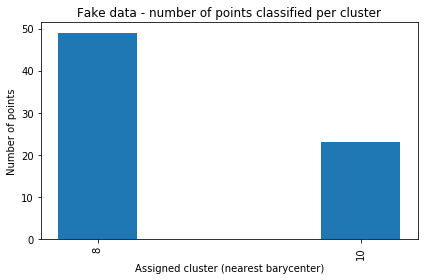

In [97]:
# ally : (N, 2) embedding (uVals / zVals) of the fake data
# barycenters : dict {region_id: (x, y)}

# ----------------------------
# 1) Prepare barycenters
# ----------------------------
bary_ids = np.array(sorted(barycenters.keys()), dtype=int)            # (K,)
bary_xy  = np.array([barycenters[i] for i in bary_ids], dtype=float)  # (K, 2)

ally_np = np.asarray(ally, dtype=float)  # (N, 2)

assert ally_np.ndim == 2 and ally_np.shape[1] == 2, "ally must have shape (N, 2)"
assert bary_xy.ndim == 2 and bary_xy.shape[1] == 2, "barycenters must be 2D coordinates"

# ----------------------------
# 2) Compute distances and assign nearest cluster
# ----------------------------
# dists[n, k] = Euclidean distance between point n and barycenter k
dists = np.linalg.norm(
    ally_np[:, None, :] - bary_xy[None, :, :],
    axis=2
)  # shape (N, K)

nearest_k = np.argmin(dists, axis=1)     # index of closest barycenter
assigned_region = bary_ids[nearest_k]    # corresponding region labels

# ----------------------------
# 3) Count points per assigned cluster
# ----------------------------
unique_regions, counts = np.unique(assigned_region, return_counts=True)

df_assigned_counts = (
    pd.DataFrame({
        "region": unique_regions.astype(int),
        "n_points": counts.astype(int)
    })
    .sort_values("region")
)

print(df_assigned_counts)

# ----------------------------
# 4) Bar plot (compact spacing)
# ----------------------------
x_pos = np.arange(len(df_assigned_counts))

fig, ax = plt.subplots(figsize=(6, 4))

ax.bar(
    x_pos,
    df_assigned_counts["n_points"],
    width=0.3
)

ax.set_xlabel("Assigned cluster (nearest barycenter)")
ax.set_ylabel("Number of points")
ax.set_title("Fake data - number of points classified per cluster")

ax.set_xticks(x_pos)
ax.set_xticklabels(df_assigned_counts["region"], rotation=90)

plt.tight_layout()
plt.show()
